In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50

from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

2026-06-07 12:13:39.820590: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780834420.063412      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780834420.131865      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780834420.659510      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780834420.659549      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780834420.659552      58 computation_placer.cc:177] computation placer alr

TensorFlow: 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [2]:
dataset_path = "/kaggle/input/datasets/sachinkumar413/diabetic-retinopathy-dataset"

In [3]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(224,224),
    batch_size=32
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(224,224),
    batch_size=32
)

class_names = train_ds.class_names

print(class_names)

Found 2750 files belonging to 5 classes.
Using 2200 files for training.


I0000 00:00:1780834477.777829      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1780834477.783901      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 2750 files belonging to 5 classes.
Using 550 files for validation.
['Healthy', 'Mild DR', 'Moderate DR', 'Proliferate DR', 'Severe DR']


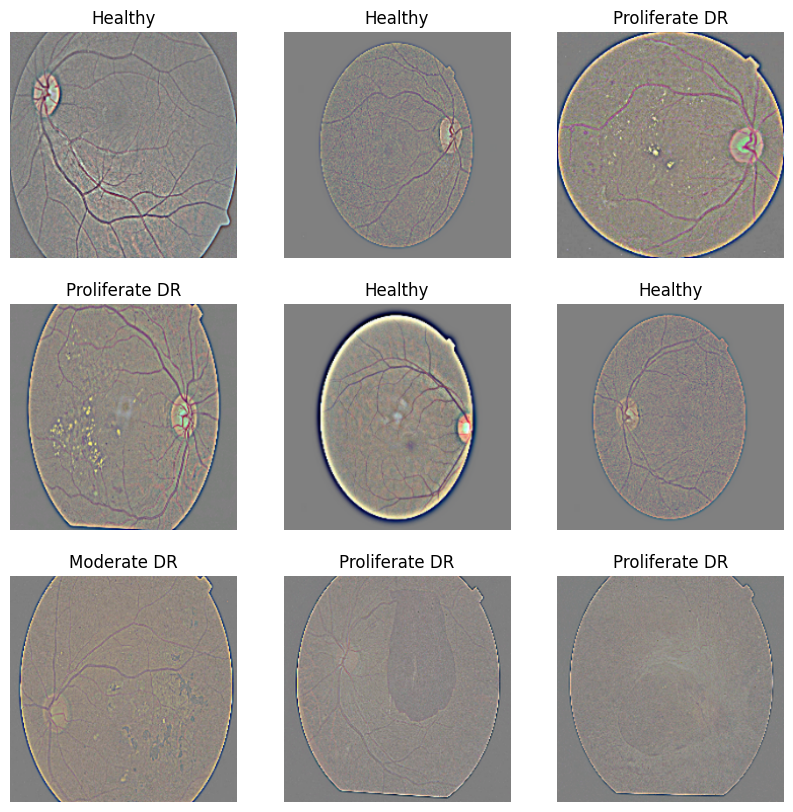

In [4]:
plt.figure(figsize=(10,10))

for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.show()

In [5]:
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

model = models.Sequential([
    base_model,

    layers.GlobalAveragePooling2D(),

    layers.Dense(
        128,
        activation='relu'
    ),

    layers.Dropout(0.5),

    layers.Dense(
        5,
        activation='softmax'
    )
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,850,629 (90.98 MB)

 Trainable params: 262,917 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [6]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10


I0000 00:00:1780834528.575588     142 service.cc:152] XLA service 0x7c89d40043d0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780834528.575640     142 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1780834528.575647     142 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1780834530.471894     142 cuda_dnn.cc:529] Loaded cuDNN version 91002


 2/69 ━━━━━━━━━━━━━━━━━━━━ 5s 75ms/step - accuracy: 0.2578 - loss: 2.0049  

I0000 00:00:1780834535.684856     142 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


69/69 ━━━━━━━━━━━━━━━━━━━━ 32s 266ms/step - accuracy: 0.6050 - loss: 1.0867 - val_accuracy: 0.6782 - val_loss: 0.8379
Epoch 2/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 7s 96ms/step - accuracy: 0.6759 - loss: 0.8863 - val_accuracy: 0.6982 - val_loss: 0.7775
Epoch 3/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 7s 97ms/step - accuracy: 0.6945 - loss: 0.8201 - val_accuracy: 0.6982 - val_loss: 0.7884
Epoch 4/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 7s 97ms/step - accuracy: 0.7073 - loss: 0.7869 - val_accuracy: 0.7055 - val_loss: 0.7516
Epoch 5/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 7s 98ms/step - accuracy: 0.7023 - loss: 0.7707 - val_accuracy: 0.7018 - val_loss: 0.7376
Epoch 6/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 7s 99ms/step - accuracy: 0.7077 - loss: 0.7674 - val_accuracy: 0.7164 - val_loss: 0.7447
Epoch 7/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 7s 100ms/step - accuracy: 0.7191 - loss: 0.7390 - val_accuracy: 0.6982 - val_loss: 0.7435
Epoch 8/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 7s 101ms/step - accuracy: 0.7127 - loss: 0.7297 - val_accuracy: 0.6964 - val_loss

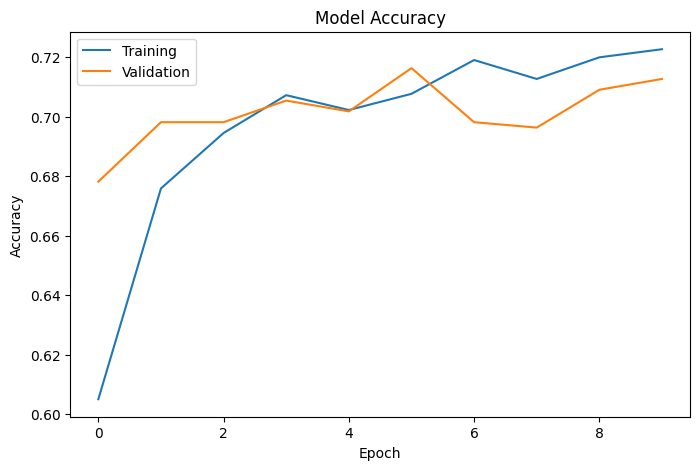

In [7]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend([
    "Training",
    "Validation"
])

plt.savefig("accuracy_curve.png")

plt.show()

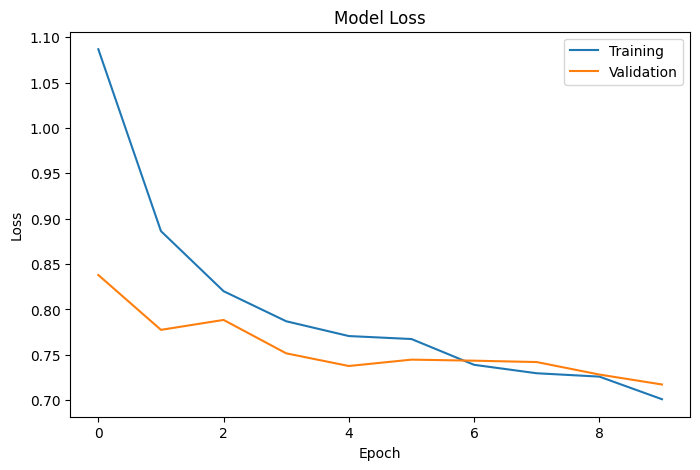

In [8]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend([
    "Training",
    "Validation"
])

plt.savefig("loss_curve.png")

plt.show()

In [9]:
val_ds_eval = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(224,224),
    batch_size=32,
    shuffle=False
)

Found 2750 files belonging to 5 classes.
Using 550 files for validation.


In [10]:
y_true = np.concatenate(
    [y for x, y in val_ds_eval],
    axis=0
)

predictions = model.predict(
    val_ds_eval
)

y_pred = np.argmax(
    predictions,
    axis=1
)

18/18 ━━━━━━━━━━━━━━━━━━━━ 9s 286ms/step


In [11]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

                precision    recall  f1-score   support

       Healthy       0.00      0.00      0.00         0
       Mild DR       0.00      0.00      0.00         0
   Moderate DR       0.14      0.97      0.24        70
Proliferate DR       1.00      0.01      0.03       290
     Severe DR       0.80      0.11      0.19       190

      accuracy                           0.17       550
     macro avg       0.39      0.22      0.09       550
  weighted avg       0.82      0.17      0.11       550



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


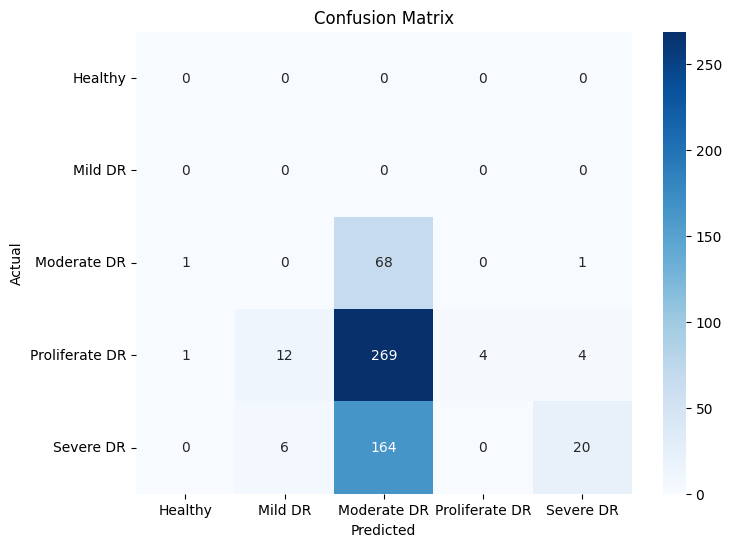

In [12]:
cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig(
    "confusion_matrix.png"
)

plt.show()

In [13]:
model.save(
    "diabetic_retinopathy_resnet50.keras"
)

print("Model Saved Successfully")

Model Saved Successfully
